# Module 4: Word Embeddings (Word2Vec & GloVe)

Word embeddings are a crucial technique in NLP that represent words as dense vectors in a continuous space. This allows us to capture semantic relationships between words - for example, the vector difference between "king" and "man" should be similar to "queen" and "woman".

### Why Word Embeddings?
- **Dense Representations**: Instead of sparse one-hot encoding (where most values are 0), embeddings are dense vectors (e.g., 100-300 dimensions)
- **Semantic Similarity**: Similar words have similar vectors (e.g., "cat" and "kitten" are close)
- **Analogy Operations**: vec("king") - vec("man") + vec("woman") ≈ vec("queen")

### Methods We'll Cover
1. **Word2Vec**: Google's algorithm using shallow neural networks
   - CBOW (Continuous Bag of Words): Predict target from context
   - Skip-gram: Predict context from target word
2. **GloVe**: Global Vectors for Word Representation
   - Uses global word-word co-occurrence statistics


## 1. Word2Vec Implementation with Gensim

We'll use Gensim's library to train our own Word2Vec model on sample text data.

In [1]:
# Import necessary libraries
import gensim
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print(f"Gensim version: {gensim.__version__}")

[nltk_data] Zip Slip blocked: punkt/


Gensim version: 4.4.0


[nltk_data] Zip Slip blocked: punkt_tab/


## 2. Prepare Training Data

We'll use a sample corpus to train our Word2Vec model.

In [2]:
# Sample corpus for training
corpus = [
    "The king is a royal person who rules over a kingdom",
    "The queen is the female ruler of a monarchy",
    "A prince is a male member of a royal family",
    "A princess is a female member of a royal family",
    "The cat is a small feline that makes a great pet",
    "The dog is a loyal canine companion to humans",
    "Cats and dogs are popular household pets",
    "The lion is known as the king of the jungle",
    "Tigers are large wild cats with stripes",
    "Dogs are domesticated wolves that evolved over thousands of years",
    "A puppy is a young dog that is可爱 and playful",
    "A kitten is a young cat that is small and curious",
    "The man walked his dog in the park yesterday",
    "The woman fed her cat some fresh fish",
    "Children love playing with puppies and kittens",
    "Royal families live in palaces and castles",
    "London is the capital city of the United Kingdom",
    "Paris is the romantic capital of France",
    "New York is a bustling metropolis in America",
    "Tokyo is the technological hub of Japan"
]

# Tokenize the corpus
tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]

print(f"Number of sentences: {len(tokenized_corpus)}")
print(f"Sample tokenized sentence: {tokenized_corpus[0]}")

Number of sentences: 20
Sample tokenized sentence: ['the', 'king', 'is', 'a', 'royal', 'person', 'who', 'rules', 'over', 'a', 'kingdom']


## 3. Train Word2Vec Model (Skip-gram)

We'll train a Skip-gram model, which learns by predicting surrounding words from a target word.

In [3]:
# Train Word2Vec model (Skip-gram)
# Parameters:
# - vector_size: Dimensionality of the word vectors
# - window: Context window size (words before and after target)
# - min_count: Minimum word frequency to be included
# - sg: 1 for Skip-gram, 0 for CBOW
# - epochs: Number of training iterations

word2vec_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,      # Embedding dimension
    window=3,            # Context window
    min_count=1,        # Include all words
    sg=1,               # Skip-gram (1) vs CBOW (0)
    epochs=100          # Training epochs
)

print(f"Vocabulary size: {len(word2vec_model.wv)}")
print(f"Vector dimension: {word2vec_model.wv.vector_size}")

Vocabulary size: 97
Vector dimension: 50


## 4. Explore Word Embeddings

Let's see what our model has learned!

In [4]:
# Get vector for a word
king_vector = word2vec_model.wv['king']
print(f"Vector for 'king' (first 10 dimensions): {king_vector[:10]}")

# Find most similar words
print("\nMost similar words to 'king':")
print(word2vec_model.wv.most_similar('king'))

print("\nMost similar words to 'cat':")
print(word2vec_model.wv.most_similar('cat'))

Vector for 'king' (first 10 dimensions): [ 0.0166891   0.0285994  -0.05154104  0.06338087  0.03507927 -0.11603288
  0.08621802  0.1009585  -0.1261132  -0.07292957]

Most similar words to 'king':
[('a', 0.9859551787376404), ('of', 0.9842792749404907), ('and', 0.984040379524231), ('in', 0.983776330947876), ('is', 0.9835460186004639), ('with', 0.9828414916992188), ('kingdom', 0.9827123880386353), ('the', 0.982554018497467), ('bustling', 0.9817252159118652), ('dogs', 0.9815455079078674)]

Most similar words to 'cat':
[('is', 0.9897782802581787), ('a', 0.9889469742774963), ('are', 0.9886263608932495), ('the', 0.9875369071960449), ('wolves', 0.9874550700187683), ('of', 0.9871101379394531), ('that', 0.9867762923240662), ('with', 0.9866501688957214), ('and', 0.9862026572227478), ('bustling', 0.9853128790855408)]


## 5. Word Analogies

One of the most powerful features of word embeddings is the ability to perform analogies:
- man : king :: woman : ?
- cat : kitten :: dog : ?

In [5]:
# Test analogies
try:
    # man : king :: woman : ?
    result = word2vec_model.wv.most_similar(positive=['woman', 'king'], negative=['man'])
    print("man : king :: woman : ?")
    print(f"Answer: {result[0][0]}")
except KeyError as e:
    print(f"Error: {e} - word not in vocabulary")

try:
    # cat : kitten :: dog : ?
    result = word2vec_model.wv.most_similar(positive=['puppy', 'cat'], negative=['kitten'])
    print("\ncat : kitten :: dog : ?")
    print(f"Answer: {result[0][0]}")
except KeyError as e:
    print(f"Error: {e} - word not in vocabulary")

man : king :: woman : ?
Answer: dogs

cat : kitten :: dog : ?
Answer: is


## 6. Visualize Embeddings with PCA

Let's reduce the dimensionality and visualize how words cluster together.

C:\Users\Ahmad\AppData\Local\Temp\ipykernel_30644\2557225985.py:20: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Ahmad\AppData\Local\Temp\ipykernel_30644\2557225985.py:20: UserWarning: Glyph 29233 (\N{CJK UNIFIED IDEOGRAPH-7231}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\setups\ml-dl\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\setups\ml-dl\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29233 (\N{CJK UNIFIED IDEOGRAPH-7231}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


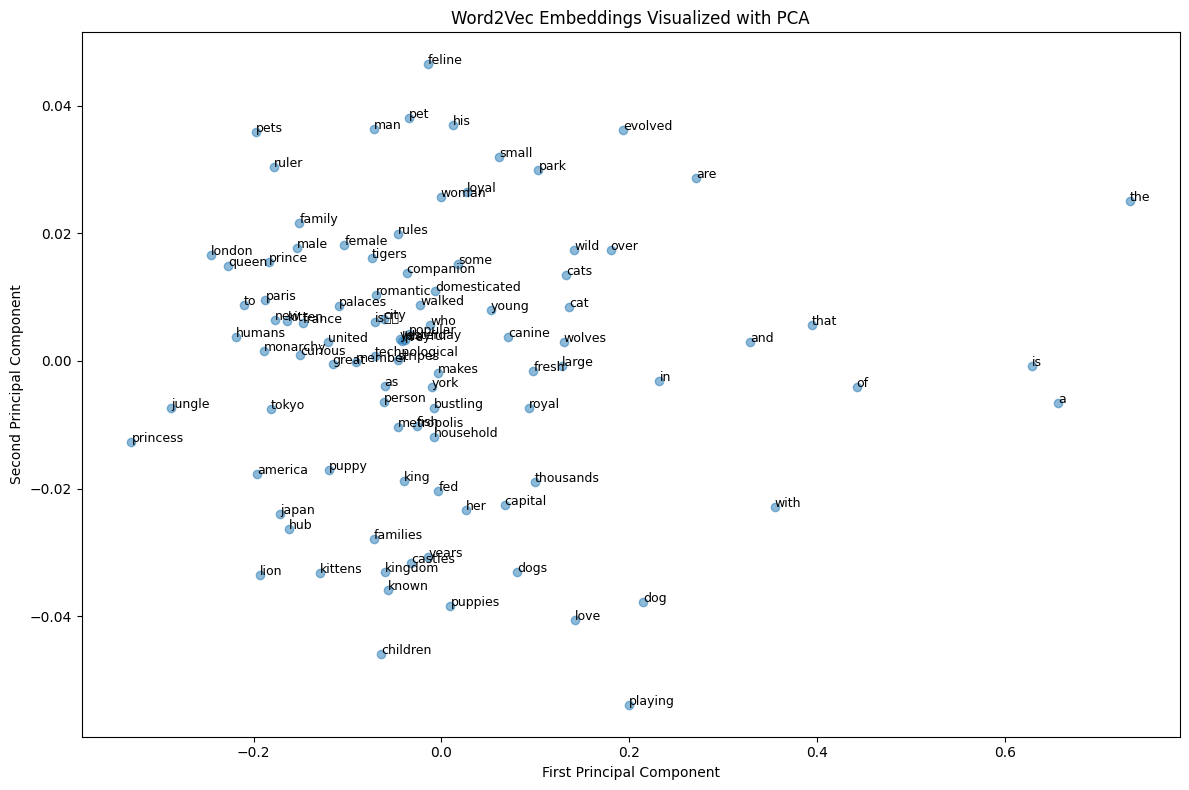

In [6]:
# Get words and their vectors
words = list(word2vec_model.wv.key_to_index.keys())
vectors = np.array([word2vec_model.wv[word] for word in words])

# Reduce to 2D using PCA
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.5)

# Add labels
for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=9)

plt.title('Word2Vec Embeddings Visualized with PCA')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.tight_layout()
plt.show()

## 7. Using Pre-trained GloVe Embeddings

Instead of training from scratch, we can use pre-trained embeddings like GloVe (trained on Wikipedia, Common Crawl, etc.).

In [7]:
# Let's demonstrate using Gensim's downloader to load pre-trained embeddings
# This downloads the GloVe embeddings (warning: large download)

import gensim.downloader as api

# Check available pre-trained models
print("Available pre-trained models:")
for model_name in list(api.info()['models'].keys())[:5]:
    print(f"  - {model_name}")

Available pre-trained models:
  - fasttext-wiki-news-subwords-300
  - conceptnet-numberbatch-17-06-300
  - word2vec-ruscorpora-300
  - word2vec-google-news-300
  - glove-wiki-gigaword-50


## 8. Load Pre-trained GloVe (Glove-Wiki-Gigaword-100)

This is a smaller 100-dimensional GloVe model trained on Wikipedia and Gigaword.

In [8]:
# Load pre-trained GloVe model
# This may take a moment to download/load
print("Loading GloVe embeddings (this may take a moment)...")
glove_model = api.load('glove-wiki-gigaword-100')

print(f"Vocabulary size: {len(glove_model)}")
print(f"Vector dimension: {glove_model.vector_size}")

Loading GloVe embeddings (this may take a moment)...
[==================================================] 100.0% 128.1/128.1MB downloaded
Vocabulary size: 400000
Vector dimension: 100


## 9. Explore Pre-trained GloVe Embeddings

In [9]:
# Find similar words
print("Most similar words to 'king':")
print(glove_model.most_similar('king')[:5])

print("\nMost similar words to 'computer':")
print(glove_model.most_similar('computer')[:5])

Most similar words to 'king':
[('prince', 0.7682328820228577), ('queen', 0.7507690787315369), ('son', 0.7020888328552246), ('brother', 0.6985775232315063), ('monarch', 0.6977890729904175)]

Most similar words to 'computer':
[('computers', 0.8751984238624573), ('software', 0.8373122215270996), ('technology', 0.7642159461975098), ('pc', 0.7366448640823364), ('hardware', 0.7290390729904175)]


In [10]:
# Perform analogies - these work much better with pre-trained embeddings!

# man : king :: woman : ?
result = glove_model.most_similar(positive=['woman', 'king'], negative=['man'])
print("man : king :: woman : ?")
print(f"Answer: {result[0][0]}")

# france : paris :: japan : ?
result = glove_model.most_similar(positive=['japan', 'paris'], negative=['france'])
print("\nfrance : paris :: japan : ?")
print(f"Answer: {result[0][0]}")

# eat : ate :: go : ?
result = glove_model.most_similar(positive=['ate', 'go'], negative=['eat'])
print("\neat : ate :: go : ?")
print(f"Answer: {result[0][0]}")

man : king :: woman : ?
Answer: queen

france : paris :: japan : ?
Answer: tokyo

eat : ate :: go : ?
Answer: went


## 10. Word Embeddings for NLP Tasks

Word embeddings can be used as input features for various NLP tasks like sentiment analysis, text classification, and named entity recognition.

In [11]:
# Example: Get embedding for a sentence by averaging word vectors

def get_sentence_embedding(sentence, model):
    """Get sentence embedding by averaging word vectors."""
    words = sentence.lower().split()
    word_vectors = []
    
    for word in words:
        if word in model:
            word_vectors.append(model[word])
    
    if word_vectors:
        return np.mean(word_vectors, axis=0)
    else:
        return None

# Get embeddings for sentences
sentences = [
    "The king rules the kingdom with wisdom",
    "A cute kitten playing with a ball of yarn",
    "The computer processes data very quickly"
]

for sentence in sentences:
    embedding = get_sentence_embedding(sentence, glove_model)
    if embedding is not None:
        print(f"'{sentence[:40]}...' -> Embedding shape: {embedding.shape}")

'The king rules the kingdom with wisdom...' -> Embedding shape: (100,)
'A cute kitten playing with a ball of yar...' -> Embedding shape: (100,)
'The computer processes data very quickly...' -> Embedding shape: (100,)


## Summary

### What We Learned:
1. **Word2Vec** - Train your own embeddings using Skip-gram or CBOW
2. **GloVe** - Use pre-trained global word vectors
3. **Word Analogies** - Perform semantic operations like king-man+woman≈queen
4. **Visualization** - Use PCA/t-SNE to visualize high-dimensional embeddings
5. **Practical Use** - Use embeddings as features for downstream NLP tasks

### Key Differences:
| Word2Vec | GloVe |
|----------|-------|
| Predictive model | Count-based model |
| Local context window | Global co-occurrence statistics |
| Faster training | Slower but often better quality |
| Smaller datasets sufficient | Requires large corpus |